# Held-out susceptible-area convergence

This notebook reads only the frozen aggregate area and decision tables. It tests numerical stability in three deterministically selected windows; it does not estimate failure probability or global hazard.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
areas = pd.read_csv(ROOT / 'data/area_convergence/area_long.csv', dtype={'region': str})
decisions = pd.read_csv(ROOT / 'data/area_convergence/decisions.csv', dtype={'region': str})
assert len(areas) == 225 and len(decisions) == 6

In [2]:
shown = decisions[['region', 'stratum', 'departure_90m', 'phase_cv', 'window_pass', 'stratum_pass']].copy()
shown['departure_90m'] = shown.departure_90m.map(lambda x: f'{x:.3f}')
shown['phase_cv'] = shown.phase_cv.map(lambda x: f'{x:.4f}')
display(shown)
failed = decisions.groupby('stratum').stratum_pass.first().to_dict()
print('Registered result:', ', '.join(f'{name}={value}' for name, value in failed.items()))
print('Both strata fail because 90 m departure exceeds 0.20 in regions 03 and 07; phase CV remains below 0.004.')

,region,stratum,departure_90m,phase_cv,window_pass,stratum_pass
0,03,glacier_contact,0.267,0.0017,no,no
1,03,permafrost,0.291,0.0006,no,no
2,07,glacier_contact,0.366,0.0023,no,no
3,07,permafrost,0.374,0.0014,no,no
4,08,glacier_contact,0.007,0.0037,yes,no
5,08,permafrost,0.142,0.0004,yes,no


Registered result: glacier_contact=no, permafrost=no
Both strata fail because 90 m departure exceeds 0.20 in regions 03 and 07; phase CV remains below 0.004.


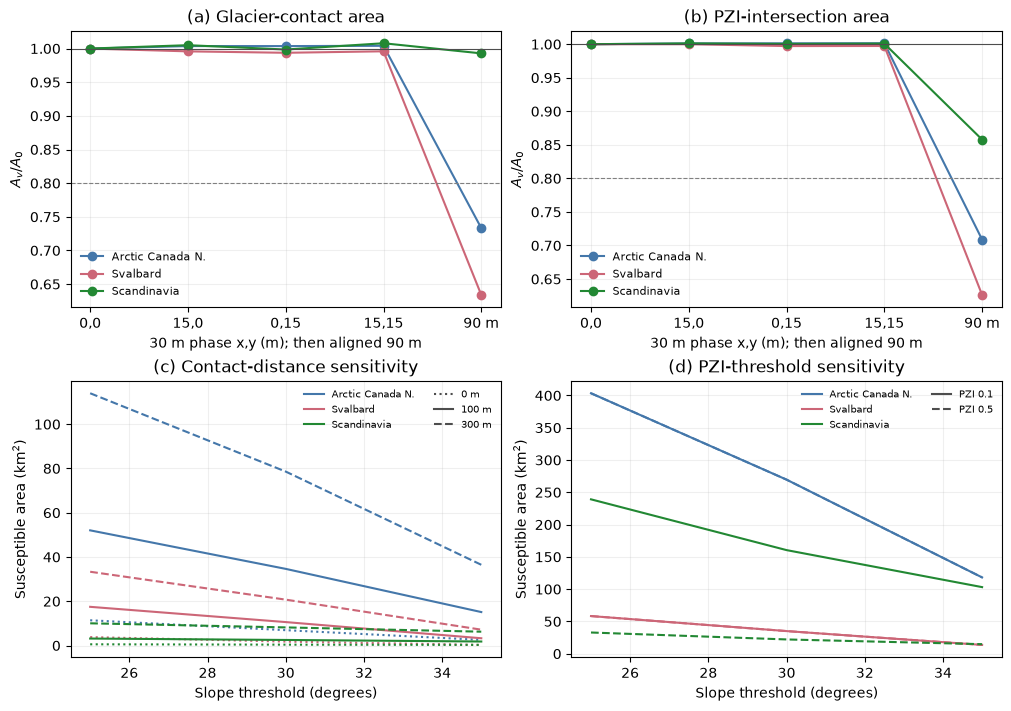

In [3]:
colors = {'03': '#4477AA', '07': '#CC6677', '08': '#228833'}
names = {'03': 'Arctic Canada N.', '07': 'Svalbard', '08': 'Scandinavia'}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
variants = ['p00', 'p10', 'p01', 'p11', 'r90']
labels = ['0,0', '15,0', '0,15', '15,15', '90 m']
for ax, stratum, title in zip(axes[0], ['glacier_contact', 'permafrost'], ['(a) Glacier-contact area', '(b) PZI-intersection area']):
    subset = areas[(areas.stratum == stratum) & (areas.slope_deg == 30)]
    subset = subset[(subset.contact_m == 100) if stratum == 'glacier_contact' else (subset.pzi_min == 0.1)]
    for region in colors:
        values = subset[subset.region == region].set_index('variant').loc[variants].area_ratio
        ax.plot(labels, values, 'o-', color=colors[region], label=names[region])
    ax.axhline(1, color='0.3', lw=0.8); ax.axhline(0.8, color='0.5', ls='--', lw=0.8)
    ax.set(title=title, ylabel='$A_v/A_0$', xlabel='30 m phase x,y (m); then aligned 90 m')
    ax.grid(alpha=0.2); ax.legend(frameon=False, fontsize=8)
contact = areas[(areas.variant == 'p00') & (areas.stratum == 'glacier_contact')]
for region in colors:
    for distance, style in zip([0, 100, 300], [':', '-', '--']):
        part = contact[(contact.region == region) & (contact.contact_m == distance)]
        axes[1, 0].plot(part.slope_deg, part.susceptible_area_m2 / 1e6, style, color=colors[region])
pzi = areas[(areas.variant == 'p00') & (areas.stratum == 'permafrost')]
for region in colors:
    for threshold, style in zip([0.1, 0.5], ['-', '--']):
        part = pzi[(pzi.region == region) & (pzi.pzi_min == threshold)]
        axes[1, 1].plot(part.slope_deg, part.susceptible_area_m2 / 1e6, style, color=colors[region])
for ax, title in zip(axes[1], ['(c) Contact-distance sensitivity', '(d) PZI-threshold sensitivity']):
    ax.set(title=title, xlabel='Slope threshold (degrees)', ylabel='Susceptible area (km$^2$)'); ax.grid(alpha=0.2)
region_handles = [Line2D([], [], color=colors[r], label=names[r]) for r in colors]
axes[1, 0].legend(handles=region_handles + [Line2D([], [], color='0.3', ls=s, label=f'{d} m') for d, s in zip([0, 100, 300], [':', '-', '--'])], frameon=False, fontsize=7, ncol=2)
axes[1, 1].legend(handles=region_handles + [Line2D([], [], color='0.3', ls=s, label=f'PZI {p}') for p, s in zip([0.1, 0.5], ['-', '--'])], frameon=False, fontsize=7, ncol=2)
for suffix in ('png', 'pdf'):
    fig.savefig(ROOT / f'figures/area_convergence.{suffix}', dpi=220 if suffix == 'png' else None, bbox_inches='tight')
plt.show()